<a href="https://colab.research.google.com/github/mishrasatyam9720-debug/biological_data_segmentation/blob/main/biological_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


In [ ]:
df=pd.read_csv("/content/Breast_GSE45827[1].csv.crdownload")
df.head(n=10)

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947
5,92,basal,7.505488,8.802820,6.235074,7.202227,2.987976,7.985281,5.413368,4.465616,...,12.284875,12.000694,13.827695,13.531900,6.413184,4.903888,5.070672,2.809652,3.628336,3.117445
6,93,basal,10.422371,8.933601,5.630488,6.881770,3.097372,6.273211,5.414001,4.432570,...,12.250015,11.951693,13.790652,13.518487,6.440627,4.952225,5.264210,2.850506,3.620385,3.072414
7,94,basal,10.190705,7.813057,6.701297,6.921350,3.140037,7.524231,5.102223,4.837492,...,12.141142,11.730830,13.806703,13.501806,6.661881,5.257033,5.501919,2.878836,3.433119,3.144263
8,99,basal,10.256077,7.796936,6.725722,7.098550,3.139031,6.885392,5.171368,4.647455,...,12.252607,11.910964,13.852896,13.651203,6.697529,5.081511,5.570573,2.972532,3.642608,3.094061
9,101,basal,9.053138,8.043154,7.655891,6.900599,2.988920,7.669423,5.417630,4.493297,...,12.160462,11.818285,13.645051,13.461486,6.388807,4.861569,5.162473,2.802148,3.461766,3.451855


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Columns: 54677 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(54675), int64(1), object(1)
memory usage: 49.2+ MB


In [ ]:
df.shape

(118, 54677)

In [ ]:
df.describe()

,samples,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,...,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,146.610169,10.228071,7.702424,6.161433,7.337610,3.193714,7.245015,5.287763,4.755087,7.778026,...,12.320732,11.788332,13.955449,13.698782,7.465045,5.590493,6.014832,2.912595,3.621807,3.172661
std,40.518020,0.621846,0.750175,0.633489,0.324040,0.157195,0.651180,0.287419,0.304009,1.672644,...,0.336497,0.396274,0.251388,0.285661,0.904444,0.855848,0.982270,0.091470,0.150163,0.107746
min,84.000000,7.505488,5.855968,4.763602,6.632206,2.830814,5.455736,4.646131,4.083044,3.866030,...,11.650564,10.939760,13.419083,13.191191,5.729767,4.326227,4.301471,2.748260,3.299401,2.937393
25%,113.250000,9.979362,7.157466,5.738983,7.109918,3.093209,6.787694,5.110148,4.531329,6.832699,...,12.125108,11.536541,13.763482,13.485455,6.774094,4.934518,5.235318,2.857750,3.533334,3.104591
50%,142.500000,10.308763,7.678419,6.215525,7.333037,3.194229,7.361479,5.228381,4.723610,7.978149,...,12.247131,11.775135,13.900564,13.639718,7.102526,5.319471,5.697563,2.905521,3.614467,3.163203
75%,173.750000,10.622786,8.150752,6.511281,7.509335,3.285902,7.711202,5.416723,4.955391,8.896605,...,12.484592,11.979748,14.119922,13.891291,8.064143,6.323692,6.975554,2.960869,3.695715,3.235556
max,231.000000,11.218541,9.627008,8.364749,8.374055,3.611630,8.484125,6.360765,5.893006,11.387102,...,13.509037,13.119966,14.622678,14.482744,10.291243,8.112206,9.121638,3.322275,4.160823,3.451855


In [ ]:
df.isnull().sum()

,0
samples,0
type,0
1007_s_at,0
1053_at,0
117_at,0
...,...
AFFX-ThrX-5_at,1
AFFX-ThrX-M_at,1
AFFX-TrpnX-3_at,1
AFFX-TrpnX-5_at,1


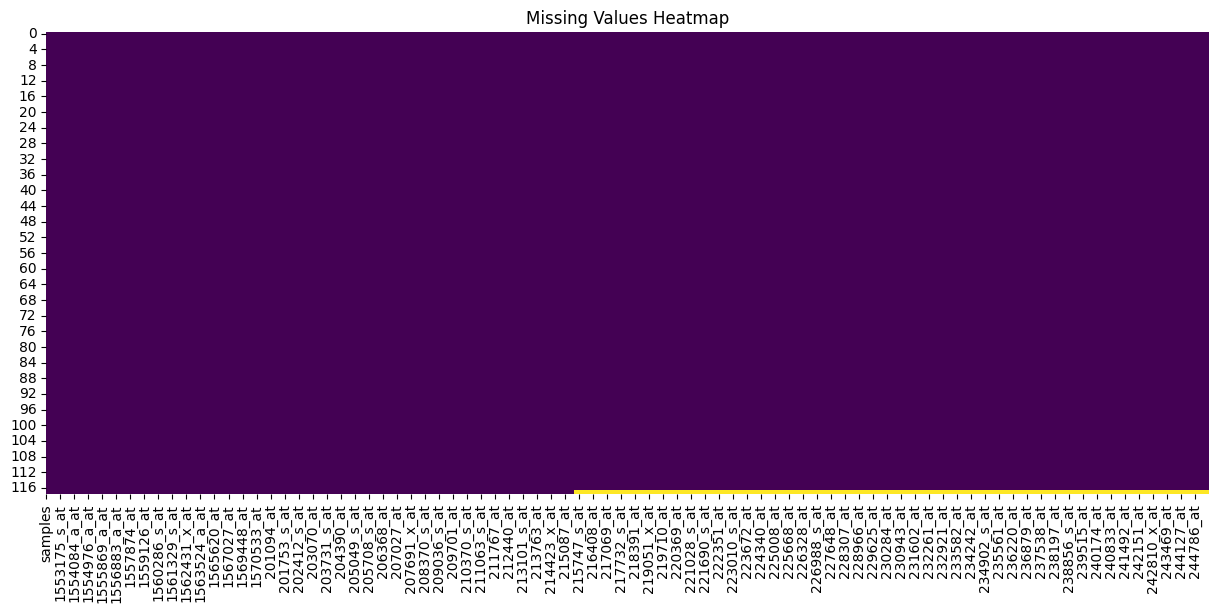

In [ ]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
df_cleaned = df.dropna()

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after dropping NaNs: {df_cleaned.shape}")

# Verify no more null values
print("\nNull values after dropping rows:")
display(df_cleaned.isnull().sum().sum())

Original DataFrame shape: (118, 54677)
Cleaned DataFrame shape after dropping NaNs: (117, 54677)

Null values after dropping rows:


np.int64(0)

In [ ]:
x=df_cleaned.iloc[:,2:]
x.shape
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
scalar=StandardScaler()
x_scaled=scalar.fit_transform(x)
pca = PCA(
    n_components=0.95,
    random_state=42
)

x_pca = pca.fit_transform(x_scaled)

print("Before PCA:", x_scaled.shape)
print("After PCA:", x_pca.shape)

print(
    "Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

Before PCA: (117, 54675)
After PCA: (117, 97)
Variance Explained: 0.9510379953200849


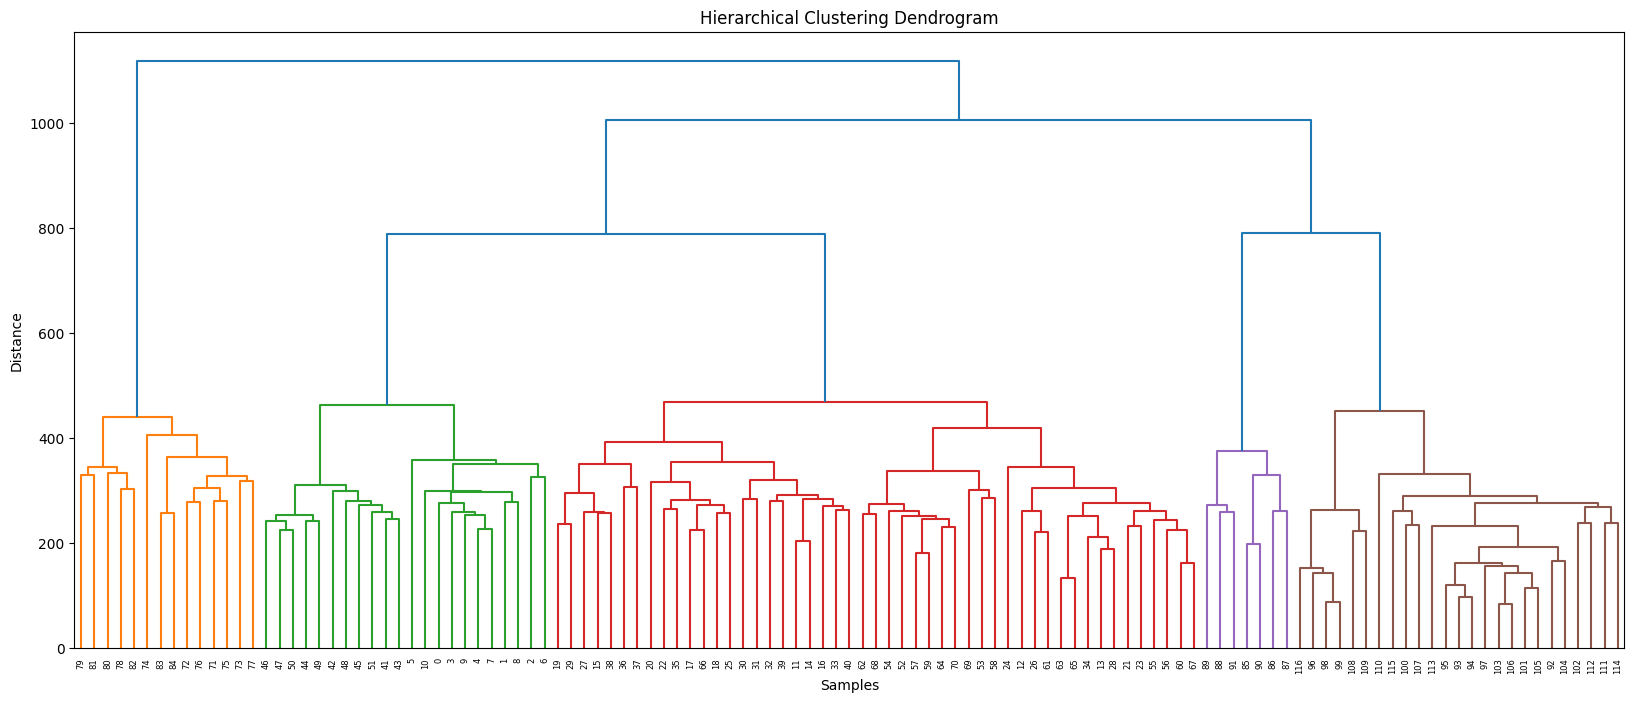

In [ ]:
plt.figure(figsize=(20, 8))
z = linkage(x_pca, method='ward')
dendrogram(
    z,
    leaf_rotation=90,
    leaf_font_size=6
)

plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [ ]:
scores = []

for k in range(2, 117):

    agg_clustering = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    clusters = agg_clustering.fit_predict(x_pca)

    silhouette = silhouette_score(x_pca, clusters)

    scores.append((k, silhouette))

best_k, best_score = max(scores, key=lambda x: x[1])

print("Best k:", best_k)
print("Best silhouette score:", best_score)

Best k: 2
Best silhouette score: 0.20960936699697444


In [ ]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.12505288 0.11120227 0.05352908 0.03773603 0.03220633 0.02768508
 0.02054106 0.01911114 0.01572398 0.01411196 0.01307067 0.01237623
 0.01146071 0.01107136 0.01030049 0.00995678 0.00974269 0.00950127
 0.00932703 0.00897497 0.00874826 0.00848859 0.00825686 0.00811728
 0.00782414 0.0077019  0.00756465 0.00730454 0.0072217  0.0071447
 0.00706616 0.00681234 0.00671357 0.00657595 0.00652433 0.00642571
 0.00635379 0.0061341  0.00608696 0.00604704 0.00582154 0.00578835
 0.0056942  0.00567947 0.00559853 0.00552451 0.00535759 0.00529095
 0.00527443 0.00521926 0.00518624 0.00509531 0.00497505 0.00495789
 0.00493189 0.00482634 0.00479168 0.00477602 0.00468421 0.00462218
 0.0045636  0.00452492 0.00450542 0.0044487  0.00432446 0.00429861
 0.00425088 0.00422946 0.00418805 0.00414864 0.00409631 0.00407348
 0.00400028 0.0039828  0.00396115 0.00391827 0.00386767 0.00383328
 0.00380482 0.00377451 0.00376647 0.00370073 0.00367171 0.00364162
 0.00359657 0.00358615 0.00349968 0.00345158 0.00342678 0.00337